## Classical Computer Vision vs. Learned Segmentation

### Classical Computer Vision

Classical computer vision uses manually designed image processing algorithms to separate objects from the background. Instead of learning from data, these methods rely on mathematical operations and predefined rules.

Typical techniques include:

- thresholding
- edge detection (Canny)
- morphological operations (erosion, dilation, opening, closing)
- contour detection
- watershed segmentation

Advantages

- No training dataset required
- Fast inference and low computational cost
- Easy to interpret because every processing step is explicitly defined
- Performs well on structured documents such as architectural floor plans

Disadvantages

- Sensitive to illumination changes and image quality
- Requires careful parameter tuning (kernel size, thresholds, etc.)
- Difficult to generalize across different drawing styles
- Cannot easily learn complex visual patterns

### Learned Segmentation (Deep Learning)

Learned segmentation replaces manually designed rules with neural networks trained on labeled examples. During training, the model automatically learns visual features such as edges, textures, corners, and semantic object representations.

Popular architectures include:

- U-Net
- SegFormer
- DeepLabV3+
- Mask R-CNN
- SAM (Segment Anything Model)

Rather than specifying segmentation rules manually, the model predicts a segmentation mask directly from the input image.

Advantages

- Learns complex visual features automatically
- More robust to variations in lighting, scale, and drawing style
- Often achieves higher segmentation accuracy than handcrafted methods
- Generalizes well when trained on diverse datasets
- Can segment objects that are difficult to describe with explicit rules

Disadvantages

- Requires labeled training data (except models such as SAM)
- Higher computational cost
- Longer training time
- Larger memory requirements

## Segment Anything Model (SAM)

The Segment Anything Model (SAM) is a state-of-the-art segmentation model developed by Meta AI. Unlike traditional segmentation networks that are trained for a specific task, SAM can generate object masks for previously unseen images without task-specific retraining. 

For example, clicking inside a room tells SAM to generate the mask corresponding to that room. Similarly, drawing a bounding box around a wall region guides SAM to segment the wall.

The image is encoded once, and different prompts can be used to generate different segmentation masks efficiently.


In [1]:
import sys
import os
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from segment_anything import sam_model_registry, SamPredictor

# Add project root to path
sys.path.append(str(Path.cwd().parent))

from src.io_utils import load_image

In [2]:
!mkdir -p ../checkpoint && wget -O ../checkpoint/sam_vit_b.pth https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

--2026-06-30 12:30:47--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.227.192.101, 13.227.192.113, 13.227.192.45, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.227.192.101|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘../checkpoint/sam_vit_b.pth’

../checkpoint/sam_v 100%[===================>] 357.67M  7.52MB/s    in 47s     

2026-06-30 12:31:35 (7.53 MB/s) - ‘../checkpoint/sam_vit_b.pth’ saved [375042383/375042383]



In [15]:
def preprocess_rooms(image):
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    # Bilateral filter to smooth noise but preserve wall edges
    denoised = cv2.bilateralFilter(gray, 9, 75, 75)
    
    # Adaptive threshold to binarize (walls -> 255, rooms -> 0)
    binary = cv2.adaptiveThreshold(
        denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY_INV, 31, 10
    )
    
    # Morphological closing to close door gaps in the walls (walls are 255)
    kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (19, 19))
    closed_walls = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel_close)
    
    # Invert binary so rooms/space is 255 and closed walls are 0
    rooms_mask = cv2.bitwise_not(closed_walls)
    
    # Morphological opening to remove text and small noise in the room space (rooms are 255)
    kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (19, 19))
    opened_rooms = cv2.morphologyEx(rooms_mask, cv2.MORPH_OPEN, kernel_open)
    
    return opened_rooms


In [16]:
def get_room_prompts(rooms_binary):
    h, w = rooms_binary.shape
    num_labels, _, stats, centroids = cv2.connectedComponentsWithStats(rooms_binary)
    
    room_boxes = []
    room_points = []
    
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        left = stats[i, cv2.CC_STAT_LEFT]
        top = stats[i, cv2.CC_STAT_TOP]
        width = stats[i, cv2.CC_STAT_WIDTH]
        height = stats[i, cv2.CC_STAT_HEIGHT]
        
        # Filter very small components (noise/text)
        if area < 500:
            continue
            
        # Filter background (typically a huge area that touches the image borders)
        if area > (h * w * 0.5):
            continue
            
        # Filter large border components representing the background
        is_border = (left <= 5 or top <= 5 or (left + width) >= (w - 5) or (top + height) >= (h - 5))
        if is_border and area > (h * w * 0.1):
            continue
            
        cx, cy = centroids[i]
        room_points.append((int(cx), int(cy)))
        room_boxes.append([left, top, left + width, top + height])
        
    return room_points, room_boxes


In [17]:
def run_sam(image, points, boxes, predictor):
    predictor.set_image(image)
    all_masks = []
    
    # Segment each room using point prompts and bounding boxes for maximum accuracy
    for pt, box in zip(points, boxes):
        input_point = np.array([pt])
        input_label = np.array([1]) # 1 indicates foreground (inside the room)
        input_box = np.array(box)
        
        masks, scores, _ = predictor.predict(
            point_coords=input_point,
            point_labels=input_label,
            box=input_box,
            multimask_output=True
        )
        
        best_mask = masks[np.argmax(scores)]
        all_masks.append(best_mask)
        
    return all_masks


In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry["vit_b"](checkpoint="../checkpoint/sam_vit_b.pth")
sam.to(device)

predictor = SamPredictor(sam)

In [19]:
# Load image
image = load_image("../output/rectified_floor_plan.png")

# Preprocess image to isolate room regions
rooms_binary = preprocess_rooms(image)

# Extract room centroids and bounding boxes
points, boxes = get_room_prompts(rooms_binary)
print(f"Detected {len(points)} candidate rooms.")

# Run SAM on the original image guided by room prompts
masks = run_sam(image, points, boxes, predictor)
print(f"Generated {len(masks)} room masks.")


Detected 13 candidate rooms.
Generated 13 room masks.


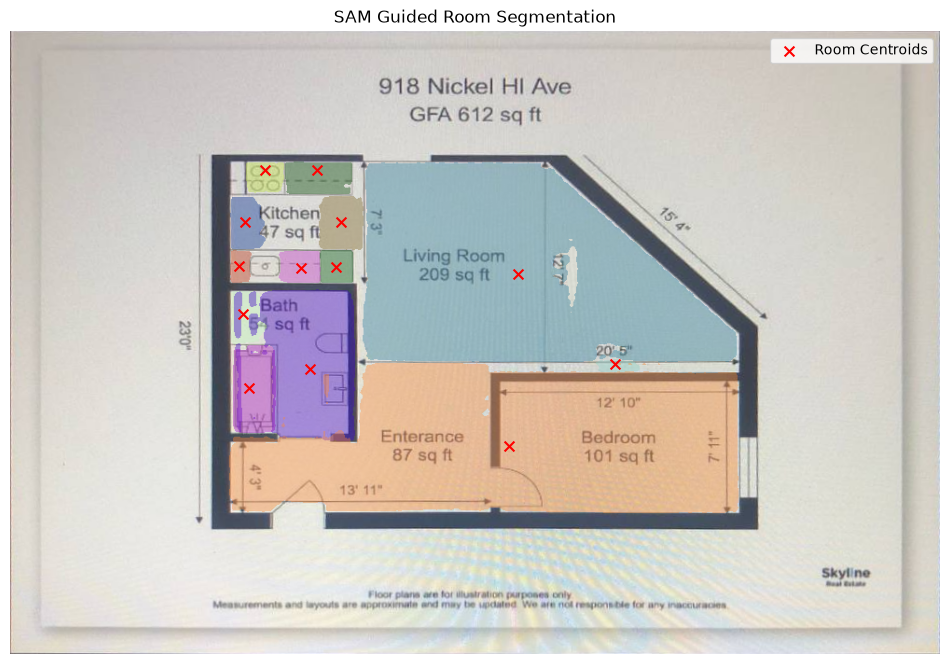

In [20]:
plt.figure(figsize=(12, 12))
plt.imshow(image)

# Plot room centroids (points)
if len(points) > 0:
    pts_arr = np.array(points)
    plt.scatter(pts_arr[:, 0], pts_arr[:, 1], color='red', marker='x', s=50, label='Room Centroids')

# Overlay the generated masks
for mask in masks:
    # Since masks is a list of boolean arrays, we overlay mask directly (fixing the original dict bug)
    overlay = np.zeros((*mask.shape, 4))
    overlay[..., :3] = np.random.random(3)
    overlay[..., 3] = mask * 0.4
    plt.imshow(overlay)

plt.axis("off")
plt.legend()
plt.title("SAM Guided Room Segmentation")
plt.show()
